In [1]:
import numpy as np
import numba
import matplotlib.pyplot as plt

# Problem Inputs/Config

In [2]:
PROBLEM_SIZE = 10_000_000 # Default for all benchmarks (unless stated otherwise)

In [3]:
X_LIST = list(range(PROBLEM_SIZE)) # Arbitrary list of size PROBLEM_SIZE
X_ARRAY = np.arange(PROBLEM_SIZE) # Arbitrary array of size PROBLEM_SIZE

Y_LIST = list(range(PROBLEM_SIZE))
Y_ARRAY = np.arange(PROBLEM_SIZE)

In [4]:
%timeit test_array_from_list = np.array(list(range(PROBLEM_SIZE)))
%timeit test_array_direct = np.arange(PROBLEM_SIZE)

319 ms ± 6.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7.84 ms ± 160 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [5]:
@numba.jit(parallel=True)
def activate_threading():
    sum = 0
    for i in numba.prange(32):
        sum += i

tmp = activate_threading() # Need to call at least one parallel function to get parallel diagnostics/options

print(numba.threading_layer()) # Just a quick check
print(numba.get_num_threads())
numba.set_num_threads(4) # 4 Threads used as standard for parallel benchmarking
print(numba.get_num_threads())

omp
20
4


# Benchmarks From Introduction

## Small Changes, Big Gains Example

In [6]:
def slow_python_mean(array):
    sum = 0
    for i in range(len(array)):
        sum += array[i]
    return sum

@numba.jit(parallel=True)
def fast_numba_mean(array):
    sum = 0
    for i in numba.prange(len(array)):
        sum += array[i]
    return sum

fast_numba_mean(X_ARRAY) # Run once to activate compilation (remove JIT-Tax from timings)

49999995000000

In [7]:
%timeit tmp = slow_python_mean(X_ARRAY)
numba.set_num_threads(4)
%timeit tmp = fast_numba_mean(X_ARRAY)

557 ms ± 8.76 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.03 ms ± 10.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Benchmarks From NumPy Section

## Never Use Python For Loops (Python/NumPy Mean) Example

In [8]:
def naive_mean(array):
  sum = 0
  for x in array:
    sum += x
  mean = sum / len(array)
  return mean
    
def np_mean(array):
  return np.mean(array)

In [9]:
# Time both functions with Python list
%timeit naive_mean(X_LIST)
%timeit np_mean(X_LIST)

136 ms ± 1.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
171 ms ± 3.65 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
# Time both functions with NumPy Array
%timeit naive_mean(X_ARRAY)
%timeit np_mean(X_ARRAY)

355 ms ± 5.22 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
5.52 ms ± 92.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
%%timeit
tmp_list = list(range(PROBLEM_SIZE))
naive_mean(tmp_list)
# Timings including list creation

241 ms ± 6.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
%%timeit
tmp_list = list(range(PROBLEM_SIZE))
tmp_array = np.array(tmp_list)
np_mean(tmp_array)
# Timings including list creation and conversion to NumPy array

272 ms ± 6.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
%%timeit
z_array = np.arange(PROBLEM_SIZE)
np_mean(z_array)
# Timings including NumPy Array intialisation

13.9 ms ± 387 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Never Use np.append() Example

In [10]:
%%timeit
x_array = np.array([])
for i in range(100_000): # Expensive For Loop!
  x_array = np.append(x_array, 5 * i) # Expensive Append Each Iteration!

1.11 s ± 43.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%%timeit
x_array = np.empty(100_000)
for i in range(len(x_array)): # Only Expensive For Loop!
  x_array[i] = 5 * i

5.46 ms ± 99 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
%%timeit
x_array = 5 * np.arange(100_000) # Ideal!

45.6 μs ± 1.85 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Monte Carlo Pi Estimation

In [14]:
def mc_pi(n_samples):
    n_samples_inside = 0
    for i in range(n_samples):
        x = np.random.random()
        y = np.random.random()
        if x**2 + y**2 <= 1:
            n_samples_inside += 1
    return 4 * n_samples_inside / n_samples

def mc_pi_np(n_samples):
    xs = np.random.random(n_samples)
    ys = np.random.random(n_samples)
    r_sqs = xs**2 + ys**2
    n_samples_inside = np.sum(r_sqs <= 1)
    return 4 * n_samples_inside / n_samples

In [15]:
%timeit mc_pi(PROBLEM_SIZE)
%timeit mc_pi_np(PROBLEM_SIZE)

4.06 s ± 41.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
99.7 ms ± 2.72 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Benchmarks From Intro to Numba Section

## JIT-ing Your First Function (Summing First N Integers) Example

In [16]:
def sum_first_N_integers(N):
    sum = 0
    for i in range(1, N+1):
        sum += i
    return sum

@numba.jit
def sum_first_N_integers_jit(N):
    sum = 0
    for i in range(1, N+1):
        sum += i
    return sum

# Alternatively
sum_first_N_integers_jit_alt = numba.jit()(sum_first_N_integers)

sum_first_N_integers_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
sum_first_N_integers_jit_alt(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)

50000005000000

In [17]:
%timeit sum_first_N_integers(PROBLEM_SIZE)
%timeit sum_first_N_integers_jit(PROBLEM_SIZE)
%timeit sum_first_N_integers_jit_alt(PROBLEM_SIZE) # Should perform the same (identical but timings always vary)

187 ms ± 3.73 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
89.1 ns ± 1.13 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
104 ns ± 1.19 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


## Monte Carlo Pi Estimation Revisited

In [18]:
def mc_pi(n_samples):
    n_samples_inside = 0
    for i in range(n_samples):
        x = np.random.random()
        y = np.random.random()
        if x**2 + y**2 <= 1:
            n_samples_inside += 1
    return 4 * n_samples_inside / n_samples

mc_pi_jit = numba.jit()(mc_pi)

def mc_pi_np(n_samples):
    xs = np.random.random(n_samples)
    ys = np.random.random(n_samples)
    r_sqs = xs**2 + ys**2
    n_samples_inside = np.sum(r_sqs <= 1)
    return 4 * n_samples_inside / n_samples

mc_pi_np_jit = numba.jit()(mc_pi_np)

mc_pi_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_np_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)

3.141182

In [19]:
%timeit mc_pi(PROBLEM_SIZE)
%timeit mc_pi_jit(PROBLEM_SIZE)
%timeit mc_pi_np(PROBLEM_SIZE)
%timeit mc_pi_np_jit(PROBLEM_SIZE)

4.11 s ± 49.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
125 ms ± 2.32 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
101 ms ± 1.67 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
150 ms ± 3.49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Unavoidable For Loops (Simple Time Integration) Example

In [20]:
def naive_time_integral(pos_0, vel_0, dt, steps, acc=-9.81):
  pos = np.zeros(steps)
  pos[0] = pos_0
  vel = np.zeros(steps)
  vel[0] = vel_0

  for i in range(1, steps):
      vel[i] = vel[i-1] + acc * dt
      pos[i] = pos[i-1] + vel[i-1] * dt

  return pos, vel

time_integral_jit = numba.jit()(naive_time_integral)

time_integral_jit(10, 0, 1e-5, PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)

(array([ 1.00000000e+01,  1.00000000e+01,  1.00000000e+01, ...,
        -4.90399657e+04, -4.90399755e+04, -4.90399853e+04],
       shape=(10000000,)),
 array([ 0.00000000e+00, -9.81000000e-05, -1.96200000e-04, ...,
        -9.80999705e+02, -9.80999804e+02, -9.80999902e+02],
       shape=(10000000,)))

In [21]:
%timeit naive_time_integral(10, 0, 1e-5, PROBLEM_SIZE)
%timeit time_integral_jit(10, 0, 1e-5, PROBLEM_SIZE)

2.46 s ± 19.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
24.1 ms ± 861 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Recursive Function (Fibonacci Sequence) Example

In [22]:
def naive_fibonacci(N):
    if N <= 1:
        return N
    else:
        return naive_fibonacci(N-1) + naive_fibonacci(N-2)

fibonacci_jit = numba.jit("int64(int64)")(naive_fibonacci)

# Custom problem size (40) due to Python slowness
fibonacci_jit(40) # Run once to activate compilation (remove JIT-Tax from timings)

102334155

In [23]:
%timeit naive_fibonacci(40)
%timeit fibonacci_jit(40)

6.34 s ± 89.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
383 ms ± 5.42 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Make Your Own NumPy Universal Functions (@vectorize) Example

In [24]:
@numba.vectorize("float64(float64, float64)")
def safe_divide(x, y):
    if y == 0.:
        return 0.
    else:
        return x / y

In [25]:
# Custom inputs just for demonstration, not benchmarking
x = 5.
y = np.array([0.,1.,2.,3.,4.,5.])
safe_divide(x,y)

array([0.        , 5.        , 2.5       , 1.66666667, 1.25      ,
       1.        ])

# Benchmarks From Numba Parallel Section

## JIT-ing First Function With parallel=True (sin2) Example

In [26]:
def np_sin2(array):
    return np.sin(array)**2

np_sin2_jit = numba.jit()(np_sin2)
np_sin2_jit_par = numba.jit(parallel=True)(np_sin2)

tmp = np_sin2_jit(X_ARRAY) # Run once to activate compilation (remove JIT-Tax from timings)
tmp = np_sin2_jit_par(X_ARRAY) # Run once to activate compilation (remove JIT-Tax from timings)

In [27]:
numba.set_num_threads(4)

%timeit tmp = np_sin2(X_ARRAY)
%timeit tmp = np_sin2_jit(X_ARRAY)
%timeit tmp = np_sin2_jit_par(X_ARRAY)

66.8 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
69.5 ms ± 721 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
19.7 ms ± 233 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Numba pranges (sin2 Python For Loop) Example

In [28]:
def python_sin2(array):
    sin2 = np.empty(len(array))

    for i in numba.prange(len(sin2)):
        sin2[i] = np.sin(array[i])**2
        
    return sin2

python_sin2_jit = numba.jit()(python_sin2)
python_sin2_jit_par = numba.jit(parallel=True)(python_sin2)

tmp = python_sin2_jit(X_ARRAY) # Run once to activate compilation (remove JIT-Tax from timings)
tmp = python_sin2_jit_par(X_ARRAY) # Run once to activate compilation (remove JIT-Tax from timings)

In [29]:
numba.set_num_threads(4)

%timeit tmp = python_sin2(X_ARRAY)
%timeit tmp = python_sin2_jit(X_ARRAY)
%timeit tmp = python_sin2_jit_par(X_ARRAY)

6.32 s ± 81.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
70.4 ms ± 1.29 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
20.1 ms ± 307 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Our Own ufunc - Now Faster Example

In [44]:
@numba.vectorize("float64(float64, float64)")
def safe_divide(x, y):
    if y == 0.0:
        return 0.0
    else:
        return x / y

@numba.vectorize("float64(float64, float64)", target="parallel")
def safe_divide_par(x, y):
    if y == 0.0:
        return 0.0
    else:
        return x / y

tmp = safe_divide(X_ARRAY, 5.) # Run once to activate compilation (remove JIT-Tax from timings)
tmp = safe_divide_par(X_ARRAY, 5.) # Run once to activate compilation (remove JIT-Tax from timings)

In [45]:
numba.set_num_threads(4)

%timeit tmp = safe_divide(X_ARRAY, 5.)
%timeit tmp = safe_divide_par(X_ARRAY, 5.)

19.2 ms ± 276 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
29.7 ms ± 708 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Monte Carlo Pi Revisited - A New Champion Example

In [32]:
def mc_pi(n_samples):
    n_samples_inside = 0
    for i in numba.prange(n_samples):
        x = np.random.random()
        y = np.random.random()
        if x**2 + y**2 <= 1:
            n_samples_inside += 1
    return 4 * n_samples_inside / n_samples

mc_pi_jit = numba.jit()(mc_pi)
mc_pi_jit_par = numba.jit(parallel=True)(mc_pi)

def mc_pi_np(n_samples):
    xs = np.random.random(n_samples)
    ys = np.random.random(n_samples)
    r_sqs = xs**2 + ys**2
    n_samples_inside = np.sum(r_sqs <= 1)
    return 4 * n_samples_inside / n_samples

mc_pi_np_jit = numba.jit()(mc_pi_np)
mc_pi_np_jit_par = numba.jit(parallel=True)(mc_pi_np)

mc_pi_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_jit_par(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_np_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_np_jit_par(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)

3.141702

In [32]:
def mc_pi(n_samples):
    n_samples_inside = 0
    for i in numba.prange(n_samples):
        x = np.random.random()
        y = np.random.random()
        if x**2 + y**2 <= 1:
            n_samples_inside += 1
    return 4 * n_samples_inside / n_samples

mc_pi_jit = numba.jit()(mc_pi)
mc_pi_jit_par = numba.jit(parallel=True)(mc_pi)

def mc_pi_np(n_samples):
    xs = np.random.random(n_samples)
    ys = np.random.random(n_samples)
    r_sqs = xs**2 + ys**2
    n_samples_inside = np.sum(r_sqs <= 1)
    return 4 * n_samples_inside / n_samples

mc_pi_np_jit = numba.jit()(mc_pi_np)
mc_pi_np_jit_par = numba.jit(parallel=True)(mc_pi_np)

mc_pi_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_jit_par(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_np_jit(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)
mc_pi_np_jit_par(PROBLEM_SIZE) # Run once to activate compilation (remove JIT-Tax from timings)

3.141702

In [33]:
numba.set_num_threads(4)

print("Pure Python")
%timeit mc_pi(PROBLEM_SIZE)
print("Numba Serial")
%timeit mc_pi_jit(PROBLEM_SIZE)
print("Numba Parallel")
%timeit mc_pi_jit_par(PROBLEM_SIZE)

print("NumPy")
%timeit mc_pi_np(PROBLEM_SIZE)
print("NumPy + Numba (Serial)")
%timeit mc_pi_np_jit(PROBLEM_SIZE)
print("NumPy + Numba (Parallel)")
%timeit mc_pi_np_jit_par(PROBLEM_SIZE)

Pure Python
4.15 s ± 53.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Numba Serial
124 ms ± 1.29 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Numba Parallel
13 ms ± 140 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
NumPy
103 ms ± 3.13 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
NumPy + Numba (Serial)
147 ms ± 2.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
NumPy + Numba (Parallel)
12.9 ms ± 151 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


3.48 μs ± 85.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
3.63 μs ± 159 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
4.11 μs ± 114 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
10.8 μs ± 146 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
70 μs ± 1.27 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
692 μs ± 5.98 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
10.4 ms ± 184 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
104 ms ± 2.35 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.12 s ± 81.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
204 ns ± 4.87 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
327 ns ± 9.63 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.43 μs ± 35.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
12.4 μs ± 121 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
120 μs ± 1.56 μs per loop (mean ± std

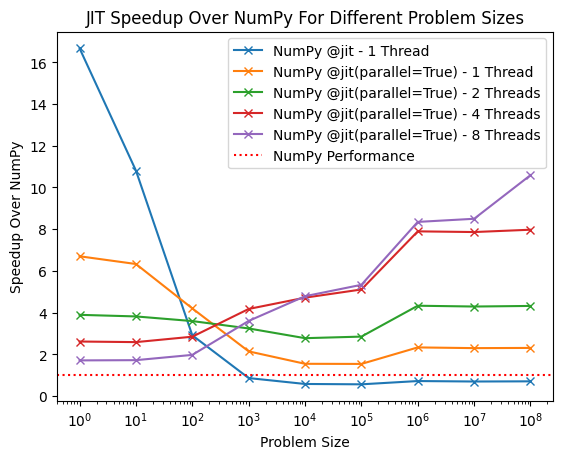

In [35]:
funcs = {"NumPy @jit": mc_pi_np_jit, "NumPy @jit(parallel=True)": mc_pi_np_jit_par}

threads_to_test = [1, 2, 4, 8]
problem_sizes = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

numpy_ref = []
for size in problem_sizes:
    time = %timeit -o mc_pi_np(size)
    numpy_ref.append(time.best)


for func_name in funcs.keys():
    if "parallel" in func_name.lower():
        threads = threads_to_test
    else:
        threads = [1]
    for thread in threads:
        numba.set_num_threads(thread)
        
        if thread == 1:
            run_name = f"{func_name} - {thread} Thread"
        else:
            run_name = f"{func_name} - {thread} Threads"

        times=[]
        for size in problem_sizes:
            time = %timeit -o funcs[func_name](size)
            times.append(time.best)

        speedup = []
        for i in range(len(times)):
            speedup.append(numpy_ref[i] / times[i])

        plt.plot(problem_sizes, speedup, label=run_name, ls="-", marker="x")

plt.axhline(y=1.0, color='r', linestyle=':', label="NumPy Performance")
plt.xscale("log")
plt.xlabel("Problem Size")
plt.ylabel("Speedup Over NumPy")
plt.title("JIT Speedup Over NumPy For Different Problem Sizes")
plt.legend()
plt.savefig("mc_pi_bench.png", dpi=300)
            